<a href="https://colab.research.google.com/github/gurudattamanpreet/Practice/blob/main/USA_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score,mean_squared_error, root_mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
import statsmodels.api as smf
from statsmodels.regression.linear_model import OLS
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/gurudattamanpreet/datasets/refs/heads/main/USA_Housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
df.drop(['Address'],axis=1,inplace=True)

In [4]:
df.shape

(5000, 6)

In [5]:
df.isna().sum()

,0
Avg. Area Income,10
Avg. Area House Age,0
Avg. Area Number of Rooms,5
Avg. Area Number of Bedrooms,6
Area Population,0
Price,0


In [6]:
df.isna().sum()/len(df)*100

,0
Avg. Area Income,0.20
Avg. Area House Age,0.00
Avg. Area Number of Rooms,0.10
Avg. Area Number of Bedrooms,0.12
Area Population,0.00
Price,0.00


It has null values which needs to be imputed by mean/median values

In [7]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,4990.000000,5000.000000,4995.000000,4994.000000,5000.000000,5.000000e+03
mean,68584.719991,5.977222,6.987693,3.981874,36163.516039,1.232073e+06
std,10651.192423,0.991456,1.005938,1.234497,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61481.465105,5.322283,6.299156,3.140000,29403.928700,9.975771e+05
50%,68797.671885,5.970429,7.002940,4.050000,36199.406690,1.232669e+06
75%,75779.145465,6.650808,7.665622,4.490000,42861.290770,1.471210e+06
max,107701.748400,9.519088,10.759588,6.500000,69621.713380,2.469066e+06


In [8]:
# df['Avg. Area Income']=df['Avg. Area Income'].fillna(df['Avg. Area Income']).mean()

In [9]:
a=['Avg. Area Income','Avg. Area Number of Rooms','Avg. Area Number of Bedrooms']
for i in a:
  df[i]=df[i].fillna(df[i].mean())

In [10]:
df.isna().sum()

,0
Avg. Area Income,0
Avg. Area House Age,0
Avg. Area Number of Rooms,0
Avg. Area Number of Bedrooms,0
Area Population,0
Price,0


<Axes: >

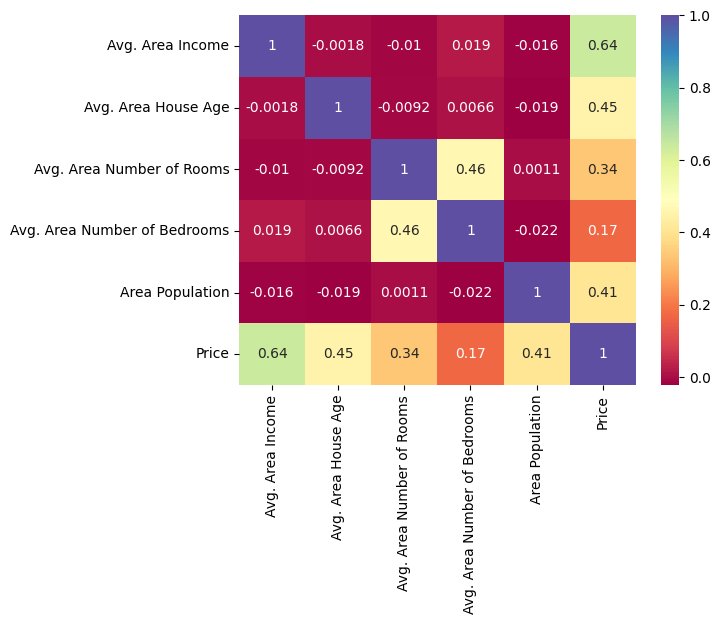

In [11]:
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),annot=True,cmap='Spectral')

we need to remove the outliers also as it a linear regression problem this needs to treated mandatory

In [11]:
# s = ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Area Population']
# for i in s:
#   sns.boxplot(df[i])
#   plt.show()

In [12]:
num=df[['Avg. Area Income','Avg. Area House Age','Avg. Area Number of Rooms','Avg. Area Number of Bedrooms','Area Population']]
Q1=num.quantile(0.25)
Q3=num.quantile(0.75)

IQR=Q3-Q1
lower_bound=Q1-1.5*IQR # 25 - 75 = -50
upper_bound=Q3+1.5*IQR # 75 + 75 = 150

lower_outliers = num<lower_bound
upper_outliers = num>upper_bound

In [13]:
print(lower_outliers.sum())

Avg. Area Income                18
Avg. Area House Age             15
Avg. Area Number of Rooms       13
Avg. Area Number of Bedrooms     0
Area Population                 12
dtype: int64


In [14]:
print(upper_outliers.sum())

Avg. Area Income                13
Avg. Area House Age             10
Avg. Area Number of Rooms       12
Avg. Area Number of Bedrooms     0
Area Population                 18
dtype: int64


Scaling se sirf appearance change hota hai, influence kam nahi hoti.

Scaling ≠ Outlier Removal.

StandardScaler data ko normalize karta hai, lekin outliers ka impact nahi kam karta.

Isliye, pehle outlier treat karo, fir scale karo.

In [26]:
df['Avg. Area Income']=np.log(df['Avg. Area Income'])
df['Avg. Area House Age']=np.log(df['Avg. Area House Age'])
df['Avg. Area Number of Rooms']=np.log(df['Avg. Area Number of Rooms'])
df['Area Population']=np.log(df['Area Population'])

In [28]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,2.408932,1.773582,1.933421,3.981874,10.452269,1.232073e+06
std,0.014544,0.172126,0.148253,1.233756,0.316042,3.531176e+05
min,2.281031,0.972408,1.174398,2.000000,5.151039,1.593866e+04
25%,2.400306,1.671902,1.840501,3.140000,10.288884,9.975771e+05
50%,2.410423,1.786819,1.946268,4.050000,10.496798,1.232669e+06
75%,2.419071,1.894738,2.036701,4.490000,10.665724,1.471210e+06
max,2.449894,2.253299,2.375797,6.500000,11.150832,2.469066e+06


In [29]:
X=df.drop(['Price'],axis=1)
y=df['Price']

In [31]:
sc=StandardScaler()
X_Scaled=sc.fit_transform(X)

In [33]:
X_train,X_test,y_train,y_test=train_test_split(X_Scaled,y,test_size=0.2,random_state=1)

In [34]:
X_train.shape

(4000, 5)

In [35]:
X_test.shape

(1000, 5)

In [36]:
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [37]:
y_pred_train=lr.predict(X_train)
y_pred_test=lr.predict(X_test)

In [57]:
r2_score(y_train,y_pred_train)

0.8902804804462028

In [58]:
r2_score(y_test,y_pred_test)

0.8687384141206693

In [55]:
mean_absolute_percentage_error(y_test,y_pred_test)
# ye 9.44% error de skta h

0.09443452748330339

In [54]:
X_train_const = smf.add_constant(X_train)
model=smf.OLS(y_train,X_train_const).fit()
model.summary()

# Always add a constant (intercept)  BIAS in OLS manually using sm.add_constant(),
# warna model.summary() ka output misleading ho sakta hai.

# endog = y values (dependent variable)
# exog = X values (independent variables)
# No functional difference, output same aayega.
# Sirf readability aur clarity ke liye endog= style preferred hota hai.

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     6482.
Date:                Mon, 05 May 2025   Prob (F-statistic):               0.00
Time:                        10:29:58   Log-Likelihood:                -52314.
No. Observations:                4000   AIC:                         1.046e+05
Df Residuals:                    3994   BIC:                         1.047e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.232e+06   1832.241    672.657      0.000    1.23e+06    1.24e+06
x1          2.278e+05   1842.196    123.667      0.000    2.24e+05    2.31e+05
x2          1.619e+05   1829.900     88.471      0.000    1.58e+05    1.65e+05
x3          1.206e+05   2076.806     58.049      0.000    1.16e+05    1.25e+05
x4          2005.7265   2058.951      0.974      0.330   -2030.967    6042.420
x5           1.52e+05   1895.818     80.172      0.000    1.48e+05    1.56e+05
==============================================================================
Omnibus:                      323.240   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              992.208
Skew:                           0.410   Prob(JB):                    3.51e-216
Kurtosis:                       5.298   Cond. No.                         1.64
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Kurtosis: Errors normal distributed hain ya nahi (outliers)

Durbin-Watson: Errors independent hain ya nahi


| Kurtosis Value | Interpretation                              |
| -------------- | ------------------------------------------- |
| ≈ 3            | ✅ Normal residuals (good)                   |
| > 3            | 🔥 Leptokurtic: Heavy tails, more outliers  |
| < 3            | 🧊 Platykurtic: Light tails, fewer outliers |




| DWatson Value | Interpretation                                       |
| -------- | ---------------------------------------------------- |
| ≈ 2      | ✅ No autocorrelation (best)                          |
| < 2      | 🔁 Positive autocorrelation (errors repeat pattern)  |
| > 2      | 🔄 Negative autocorrelation (errors alternate signs) |


In [65]:
variable=X_Scaled
vif=pd.DataFrame()
vif['VIF']=[variance_inflation_factor(variable,i) for i in range(variable.shape[1])]
vif['Features']=X.columns

In [66]:
vif

,VIF,Features
0,1.001314,Avg. Area Income
1,1.000663,Avg. Area House Age
2,1.264029,Avg. Area Number of Rooms
3,1.264574,Avg. Area Number of Bedrooms
4,1.001053,Area Population


🎯 General VIF Rules:

VIF Value Interpretation

1 Perfectly independent (best!)

1–5 👍 Acceptable — weak correlation

5–10 ⚠️ Moderate multicollinearity (watch)

10 greater 🚨 High multicollinearity (remove!)